# Superstore EDA

In [12]:
import pandas as pd

# latin-1: CSV has non-UTF-8 bytes (e.g. 0xa0 / 0xf6)
df = pd.read_csv("superstore.csv", encoding="latin-1")
print(df.shape)
print(df.columns.tolist())
display(df.head())
df.info()

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [14]:
# dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["ShipDays"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Year"] = df["Order Date"].dt.year
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

# sanity
print(df[["Sales", "Quantity", "Discount", "Profit", "ShipDays"]].describe())
print("discount unique:", sorted(df["Discount"].unique()))
print("qty min/max:", df["Quantity"].min(), df["Quantity"].max())
print("profit < 0 rows:", (df["Profit"] < 0).sum())
print("sales <= 0 rows:", (df["Sales"] <= 0).sum())
print("country:", df["Country"].unique())
print("duplicate Row ID:", df["Row ID"].duplicated().sum())
print("orders:", df["Order ID"].nunique(), "customers:", df["Customer ID"].nunique())

              Sales     Quantity     Discount       Profit     ShipDays
count   9994.000000  9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001     3.789574     0.156203    28.656896     3.958175
std      623.245101     2.225110     0.206452   234.260108     1.747567
min        0.444000     1.000000     0.000000 -6599.978000     0.000000
25%       17.280000     2.000000     0.000000     1.728750     3.000000
50%       54.490000     3.000000     0.200000     8.666500     4.000000
75%      209.940000     5.000000     0.200000    29.364000     5.000000
max    22638.480000    14.000000     0.800000  8399.976000     7.000000
discount unique: [np.float64(0.0), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.3), np.float64(0.32), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8)]
qty min/max: 1 14
profit < 0 rows: 1871
sales <= 0 rows: 0
country: ['United States']
duplicate Row ID: 0
orders: 5009 customer

In [4]:
df["ProfitMargin"] = df["Profit"] / df["Sales"]

In [5]:
df["DiscountBin"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0, 0.2, 0.3, 0.5, 1],
    labels=["0%", "1–20%", "21–30%", "31–50%", "51–80%"],
)

leak = (
    df.groupby(["Sub-Category", "DiscountBin"], observed=True)
      .agg(
          lines=("Row ID", "size"),
          sales=("Sales", "sum"),
          profit=("Profit", "sum"),
          avg_discount=("Discount", "mean"),
      ).reset_index()
)
leak["margin"] = leak["profit"] / leak["sales"]

# worst profit first
leak.sort_values("profit").head(20)

,Sub-Category,DiscountBin,lines,sales,profit,avg_discount,margin
9,Binders,51–80%,613,36140.6130,-38510.4964,0.738010,-1.065574
47,Tables,31–50%,122,64774.3900,-27295.8952,0.434016,-0.421399
34,Machines,51–80%,23,15601.5090,-19579.3191,0.700000,-1.254963
33,Machines,31–50%,25,57481.2940,-10302.0725,0.448000,-0.179225
4,Appliances,51–80%,67,3382.5340,-8629.6412,0.800000,-2.551236
17,Chairs,21–30%,158,70005.5020,-6737.1167,0.300000,-0.096237
13,Bookcases,31–50%,45,21801.9188,-6646.9494,0.392000,-0.304879
39,Phones,31–50%,109,34337.3520,-6385.7854,0.400000,-0.185972
27,Furnishings,51–80%,138,6644.7000,-5944.6552,0.600000,-0.894646
41,Storage,1–20%,316,65989.8480,-4249.3451,0.200000,-0.064394


In [6]:
(
    df.groupby("Sub-Category")
      .agg(sales=("Sales", "sum"), profit=("Profit", "sum"),
           lines=("Row ID", "size"), avg_disc=("Discount", "mean"))
      .assign(margin=lambda x: x["profit"] / x["sales"])
      .sort_values("profit")
)

,sales,profit,lines,avg_disc,margin
Sub-Category,,,,,
Tables,206965.5320,-17725.4811,319,0.261285,-0.085645
Bookcases,114879.9963,-3472.5560,228,0.211140,-0.030228
Supplies,46673.5380,-1189.0995,190,0.076842,-0.025477
Fasteners,3024.2800,949.5182,217,0.082028,0.313965
Machines,189238.6310,3384.7569,115,0.306087,0.017886
Labels,12486.3120,5546.2540,364,0.068681,0.444187
Art,27118.7920,6527.7870,796,0.074874,0.240711
Envelopes,16476.4020,6964.1767,254,0.080315,0.422676
Furnishings,91705.1640,13059.1436,957,0.138349,0.142404


,margin,profit
DiscountBin,,
0%,0.340160,320987.6032
1–20%,0.174368,100785.4745
21–30%,-0.115481,-10369.2774
31–50%,-0.296062,-48447.7273
51–80%,-1.138785,-76559.0513


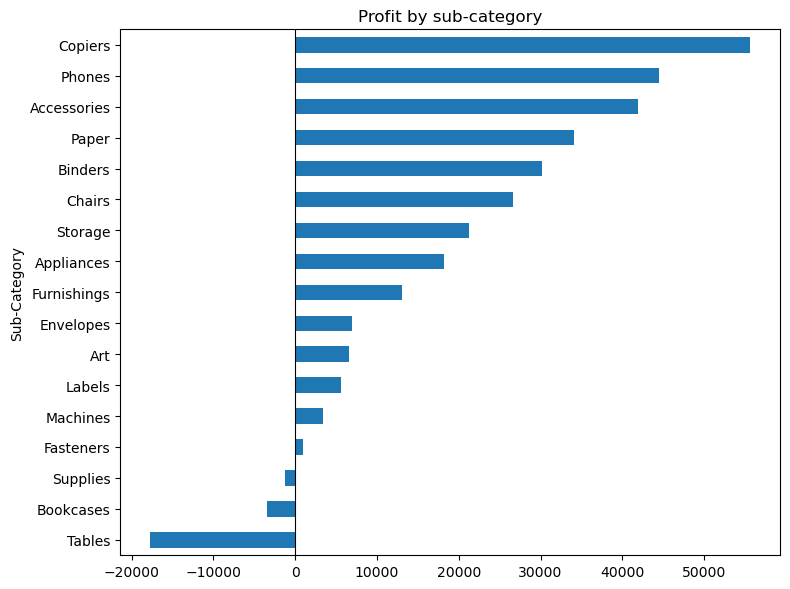

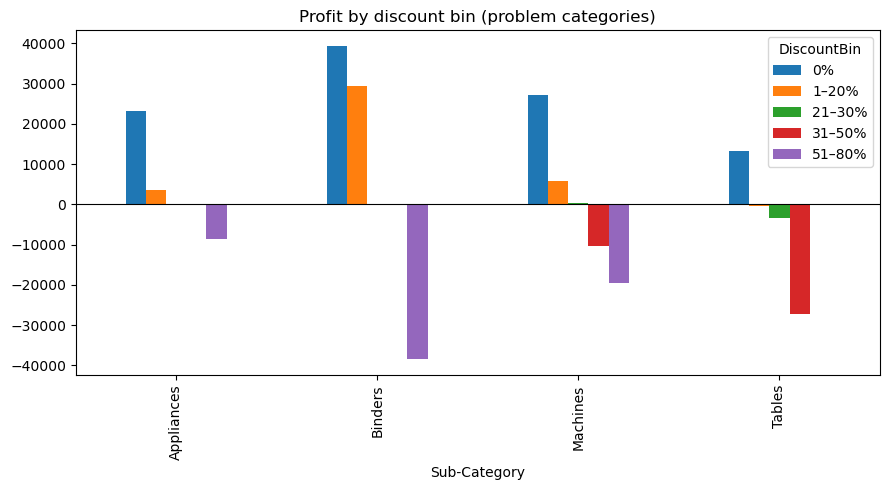

In [7]:
import matplotlib.pyplot as plt

# A — net profit by sub-category
sub = (
    df.groupby("Sub-Category")["Profit"].sum()
      .sort_values()
)
ax = sub.plot(kind="barh", figsize=(8, 6))
ax.set_title("Profit by sub-category")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("profit_by_subcategory.png", dpi=150)

# B — Binder / Table / Appliance profit by discount bin
focus = df[df["Sub-Category"].isin(["Binders", "Tables", "Appliances", "Machines"])]
pivot = (
    focus.groupby(["Sub-Category", "DiscountBin"], observed=True)["Profit"]
         .sum()
         .unstack()
)
pivot.plot(kind="bar", figsize=(9, 5), title="Profit by discount bin (problem categories)")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("profit_by_discount_bin.png", dpi=150)

# C — optional: margin vs discount (binned means)
(
    df.groupby("DiscountBin", observed=True)
      .agg(margin=("ProfitMargin", "mean"), profit=("Profit", "sum"))
)

In [8]:
pair = (
    df.groupby(["Region", "Segment"])
      .agg(
          orders=("Order ID", "nunique"),
          lines=("Row ID", "size"),
          sales=("Sales", "sum"),
          profit=("Profit", "sum"),
          avg_disc=("Discount", "mean"),
      )
)
pair["margin"] = pair["profit"] / pair["sales"]
pair.sort_values("profit")

orders  lines        sales      profit  avg_disc  \
Region  Segment                                                         
South   Home Office     131    272   74255.0015   4620.6343  0.143382   
Central Consumer        604   1212  252031.4340   8564.0481  0.252030   
        Home Office     223    438   91212.6440  12438.4124  0.208858   
South   Corporate       247    510  121885.9325  15215.2232  0.157745   
West    Home Office     301    571  136721.7770  16530.4150  0.106918   
Central Corporate       348    673  157995.8128  18703.9020  0.239822   
East    Corporate       434    877  200409.3470  23622.5789  0.144356   
        Home Office     254    502  127463.7260  26709.2168  0.141036   
South   Consumer        444    838  195580.9710  26913.5728  0.142124   
West    Corporate       485    960  225855.2745  34437.4299  0.113958   
East    Consumer        713   1469  350908.1670  41190.9843  0.147447   
West    Consumer        825   1672  362880.7730  57450.6040  0.107506   

                       margin  
Region  Segment                
South   Home Office  0.062227  
Central Consumer     0.033980  
        Home Office  0.136367  
South   Corporate    0.124832  
West    Home Office  0.120906  
Central Corporate    0.118382  
East    Corporate    0.117872  
        Home Office  0.209544  
South   Consumer     0.137608  
West    Corporate    0.152476  
East    Consumer     0.117384  
West    Consumer     0.158318

In [9]:
ship = (
    df.groupby("Ship Mode")
      .agg(
          lines=("Row ID", "size"),
          orders=("Order ID", "nunique"),
          sales=("Sales", "sum"),
          profit=("Profit", "sum"),
          avg_disc=("Discount", "mean"),
          pct_neg=("Profit", lambda s: (s < 0).mean()),
      )
)
ship["margin"] = ship["profit"] / ship["sales"]
ship

,lines,orders,sales,profit,avg_disc,pct_neg,margin
Ship Mode,,,,,,,
First Class,1538,787,3.514284e+05,48969.8399,0.164610,0.190507,0.139345
Same Day,543,264,1.283631e+05,15891.7589,0.152394,0.180479,0.123803
Second Class,1945,964,4.591936e+05,57446.6354,0.138895,0.157841,0.125103
Standard Class,5968,2994,1.358216e+06,164088.7875,0.160023,0.196548,0.120812


In [10]:
cap = 0.20
sim = df.copy()
sim["cost"] = sim["Sales"] - sim["Profit"]

# avoid div/0; Discount max is 0.8 so OK
sim["list_sales"] = sim["Sales"] / (1 - sim["Discount"]).replace(0, 1)
sim["new_discount"] = sim["Discount"].clip(upper=cap)
sim["new_sales"] = sim["list_sales"] * (1 - sim["new_discount"])
sim["new_profit"] = sim["new_sales"] - sim["cost"]

# only lines the cap would change
hit = sim["Discount"] > cap

print("lines affected:", int(hit.sum()))
print("historical profit:", sim["Profit"].sum())
print("counterfactual profit:", sim["new_profit"].sum())
print("delta:", sim["new_profit"].sum() - sim["Profit"].sum())

# where the delta comes from
(
    sim[hit]
    .groupby("Sub-Category")
    .agg(
        lines=("Row ID", "size"),
        old_profit=("Profit", "sum"),
        new_profit=("new_profit", "sum"),
    )
    .assign(delta=lambda x: x["new_profit"] - x["old_profit"])
    .sort_values("delta", ascending=False)
)

lines affected: 1393
historical profit: 286397.0217
counterfactual profit: 505588.0159
delta: 219190.99420000002


,lines,old_profit,new_profit,delta
Sub-Category,,,,
Binders,613,-38510.4964,39832.1546,78342.6510
Machines,53,-29555.3521,26260.2279,55815.5800
Tables,176,-30698.2228,-1197.7948,29500.4280
Bookcases,70,-11097.7614,555.7678,11653.5292
Phones,109,-6385.7854,5059.9986,11445.7840
Appliances,67,-8629.6412,1517.9608,10147.6020
Chairs,158,-6737.1167,3263.6693,10000.7860
Furnishings,138,-5944.6552,700.0448,6644.7000
Copiers,9,2182.9752,7822.9092,5639.9340
